In [1]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [2]:
# Load CSV file with image labels
data_path = r"E:\Junaed_Jibon\Model_Training\updated_train_dataset.csv"
image_dir = r"E:\Junaed_Jibon\Model_Training\Train_images"

In [3]:
# Load the CSV file into a pandas DataFrame
data = pd.read_csv(data_path)

# Create a full file path column; assumes 'image_id' column holds image filenames
data['file_path'] = data['Image_Id'].apply(lambda x: os.path.join(image_dir, x))

# Ensure that the labels are treated as strings (for categorical classification)
data['label'] = data['Label'].astype(str)

In [4]:
# Parameters for image dimensions, batch size, and training epochs
img_height, img_width = 299, 299  # InceptionV3 default input size is 299x299
batch_size = 32
epochs = 25

In [5]:
# Create an ImageDataGenerator with rescaling and a validation split
data_gen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.1111  # Approximately 10% validation data
)

# Flow training images from the DataFrame
train_gen = data_gen.flow_from_dataframe(
    dataframe=data,
    directory=None,  # 'file_path' already contains the full path
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Flow validation images from the DataFrame
val_gen = data_gen.flow_from_dataframe(
    dataframe=data,
    directory=None,  # 'file_path' already contains the full path
    x_col='file_path',
    y_col='label',
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 4151 validated image filenames belonging to 8 classes.
Found 518 validated image filenames belonging to 8 classes.


In [6]:
# Load the InceptionV3 model with pretrained ImageNet weights, excluding the top layers.
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [7]:
# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
# Adjust the final Dense layer for the number of classes; here 8 classes are assumed.
predictions = Dense(8, activation='softmax')(x)

In [8]:
# Create the complete model.
model = Model(inputs=base_model.input, outputs=predictions)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [10]:
# Define callbacks for reducing the learning rate and early stopping.
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=4,
        verbose=1,
        restore_best_weights=True
    )
]

In [11]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    steps_per_epoch=train_gen.samples // batch_size,
    validation_steps=val_gen.samples // batch_size,
    callbacks=callbacks
)

Epoch 1/25
129/129 [==============================] - 68s 458ms/step - loss: 1.8587 - accuracy: 0.3219 - val_loss: 1.4990 - val_accuracy: 0.5234 - lr: 1.0000e-05
Epoch 2/25
129/129 [==============================] - 57s 443ms/step - loss: 1.2057 - accuracy: 0.6363 - val_loss: 0.9707 - val_accuracy: 0.7070 - lr: 1.0000e-05
Epoch 3/25
129/129 [==============================] - 57s 441ms/step - loss: 0.7627 - accuracy: 0.7842 - val_loss: 0.6313 - val_accuracy: 0.8301 - lr: 1.0000e-05
Epoch 4/25
129/129 [==============================] - 58s 445ms/step - loss: 0.4934 - accuracy: 0.8706 - val_loss: 0.4385 - val_accuracy: 0.8828 - lr: 1.0000e-05
Epoch 5/25
129/129 [==============================] - 57s 443ms/step - loss: 0.3087 - accuracy: 0.9284 - val_loss: 0.3196 - val_accuracy: 0.9141 - lr: 1.0000e-05
Epoch 6/25
129/129 [==============================] - 59s 452ms/step - loss: 0.1942 - accuracy: 0.9614 - val_loss: 0.2534 - val_accuracy: 0.9316 - lr: 1.0000e-05
Epoch 7/25
129/129 [========

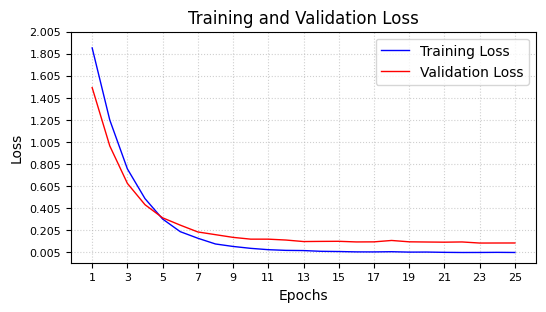

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_loss(history):
    # Check if history object is valid
    epochs = range(1, len(history.history['loss']) + 1)
    
    plt.figure(figsize=(6, 3))  # More horizontal layout
    
    # Plot loss curves
    plt.plot(epochs, np.array(history.history['loss']), label='Training Loss', 
             color='blue', linestyle='-', linewidth=1)
    
    if 'val_loss' in history.history:
        plt.plot(epochs, np.array(history.history['val_loss']), label='Validation Loss', 
                 color='red', linestyle='-', linewidth=1)

    plt.title('Training and Validation Loss', fontsize=12)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.legend(fontsize=10, loc='upper right')
    plt.grid(linestyle='dotted', alpha=0.6)

    # Dynamically adjust x-axis ticks
    interval = 2 if len(epochs) <= 50 else 5
    plt.xticks(range(1, len(epochs) + 1, interval), fontsize=8)
    
    # Set y-axis dynamically based on loss values
    min_loss = min(min(history.history['loss']), min(history.history.get('val_loss', [float('inf')])))
    max_loss = max(max(history.history['loss']), max(history.history.get('val_loss', [-float('inf')])))
    plt.yticks(np.arange(min_loss, max_loss + 0.2, 0.2), fontsize=8)  

    plt.show()
    
plot_loss(history)


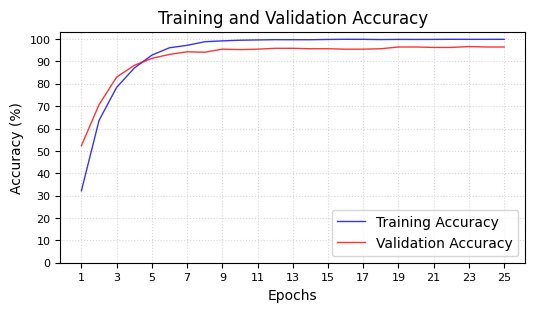

In [14]:
# Evaluate the model
eval_result = model.evaluate(val_gen)
print(f"Validation Loss: {eval_result[0]}, Validation Accuracy: {eval_result[1]}")

17/17 [==============================] - 6s 362ms/step - loss: 0.0906 - accuracy: 0.9653
Validation Loss: 0.09059339016675949, Validation Accuracy: 0.9652509689331055


In [15]:
# Save the model
model.save('InceptionV3_Model.h5')